# Thailand Food Inflation Analysis Project

## 1. Introduction

This analysis explores food price trends and inflation in Thailand between 2000 and 2020 using wholesale food price data form Kaggle.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load data
thai_food_inflation = pd.read_csv("../data/cleaned_data/thai_food_inflation.csv")

### Overview of the Datas

In [5]:
# see how much product we have
thai_food_inflation['product'].value_counts()

product
Maize - Wholesale             243
Rice - Wholesale              243
Cassava flour - Wholesale     240
Meat (chicken) - Wholesale    123
Name: count, dtype: int64

In [6]:
thai_food_inflation['year'].min()

np.int64(2000)

In [ ]:
thai_food_inflation['year'].max()

np.int64(2020)

In [ ]:
# no null ieft in this data
thai_food_inflation.isnull().sum()

country           0
product           0
price             0
month             0
year              0
unit              0
inflation_rate    0
dtype: int64

## 2. Price Trends Overtime

In [9]:
yearly_prices = (
    thai_food_inflation # dataframe
    .groupby(['year', 'product'])['price'] # group by
    .mean() # average
    .reset_index() # turn it back to normal column
)

In [10]:
yearly_prices

,year,product,price
0,2000,Cassava flour - Wholesale,5.191667
1,2000,Maize - Wholesale,4.710167
2,2000,Rice - Wholesale,6.841500
3,2001,Cassava flour - Wholesale,6.841667
4,2001,Maize - Wholesale,4.355667
...,...,...,...
69,2019,Rice - Wholesale,10.821950
70,2020,Cassava flour - Wholesale,12.775000
71,2020,Maize - Wholesale,8.503333
72,2020,Meat (chicken) - Wholesale,46.743333


#### Average price trend overtimes

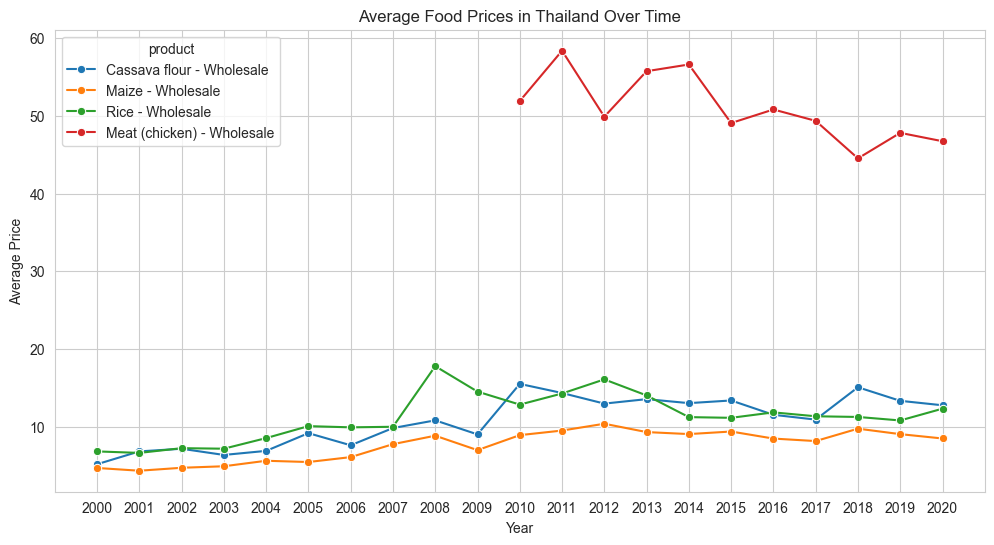

In [ ]:
# plot a simple graph to see average price overtime
sns.set_style("whitegrid") # use whitegrid

plt.figure(figsize=(12,6)) # figure size

sns.lineplot( # line graph
    data=yearly_prices, # data = yearly_prices
    x='year', # x-axis
    y='price', # y-axis
    hue='product', # legends
    marker='o' # dot as a marker
)

plt.title('Average Food Prices in Thailand Over Time') # title of the graph
plt.xlabel('Year') # x-axis label
plt.ylabel('Average Price') # y-axis label

plt.xticks(yearly_prices['year'].unique()) # make year as year not average or make graph look beutiful
#plt.xticks(rotation=45) # If you want to rotation the x axis 

plt.show()

As you can see the others data except Meat Chicken are all cover year's 2000-2009 which Chicken started at 2010. So, we will plot chicken seperately.

In [14]:
# Cassava flour, Maize, Rice
staple_foods = yearly_prices[
    yearly_prices['product'] != 'Meat (chicken) - Wholesale'
]

# Only Chicken
chicken = yearly_prices[
    yearly_prices['product'] == 'Meat (chicken) - Wholesale'
]

##### 2.1 Staple food Analysis

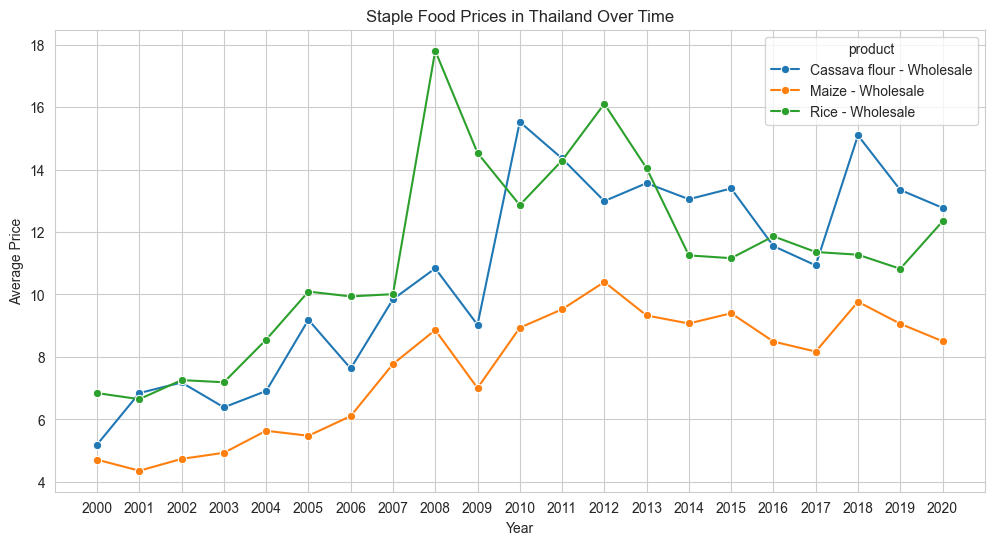

In [15]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=staple_foods,
    x='year',
    y='price',
    hue='product',
    marker='o'
)

plt.title('Staple Food Prices in Thailand Over Time')
plt.xlabel('Year')
plt.ylabel('Average Price')

plt.xticks(staple_foods['year'].unique())

plt.show()

### Key Insight

Staple food prices in Thailand showed a gradual upward trend between 2000 and 2020.

Rice prices experienced the highest volatility among staple foods, including a sharp increase around 2008, which may reflect global food price pressures during that period.

Maize prices remained relatively stable compared to other staple foods, while cassava flour prices showed moderate long-term growth with several noticeable fluctuations after 2010.

##### 2.2 Chicken Price Analysis

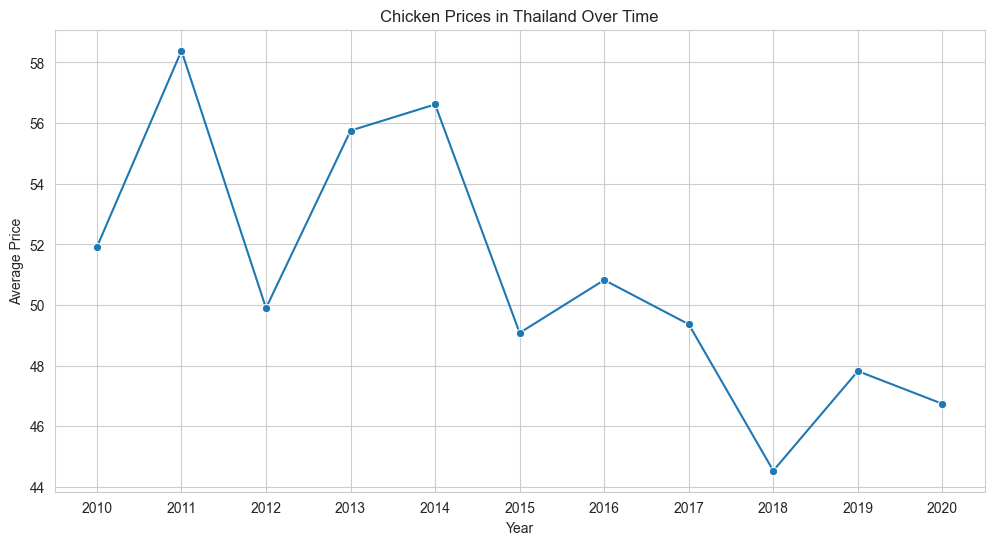

In [18]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=chicken,
    x='year',
    y='price',
    marker='o'
)

plt.title('Chicken Prices in Thailand Over Time')
plt.xlabel('Year')
plt.ylabel('Average Price')

plt.xticks(chicken['year'].unique())

plt.show()

### Key Insight

Chicken prices were significantly higher than staple food prices throughout the observed period.

Prices peaked around 2011–2014 before gradually declining after 2015.

Compared to staple foods, chicken prices demonstrated greater volatility, suggesting that protein-related food products may be more sensitive to market conditions, production costs, or supply chain disruptions.

## 3. Inflation rate vs Food Prices

In [17]:
yearly_inflation = (
    thai_food_inflation
    .groupby('year')
    .agg({
        'price': 'mean', # arrgregration price and inflation_rate in average by year
        'inflation_rate': 'mean'
    })
    .reset_index()
)

yearly_inflation.head() # look first 5 index

,year,price,inflation_rate
0,2000,5.581111,1.591969
1,2001,5.947917,1.626909
2,2002,6.391108,0.697309
3,2003,6.167667,1.804350
4,2004,7.032072,2.759149


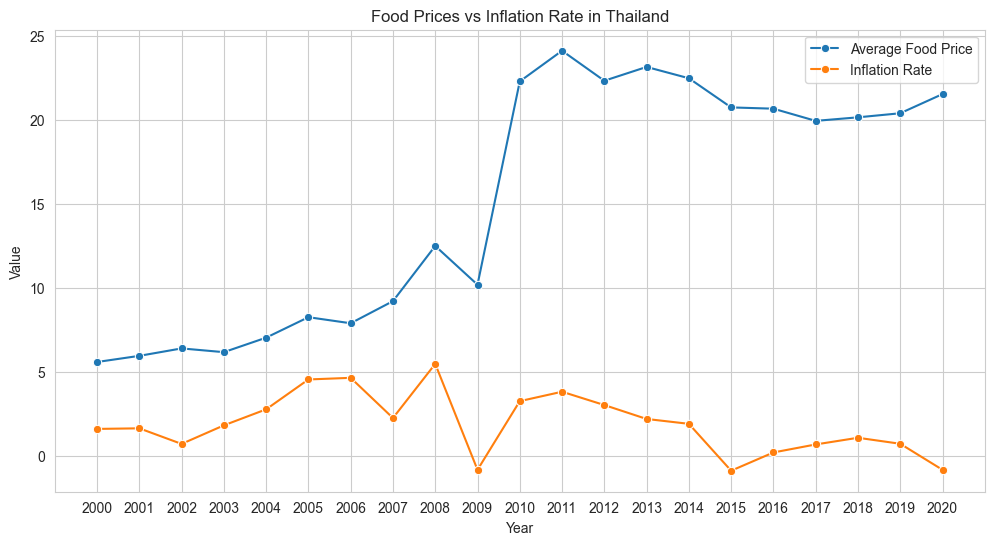

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_inflation,
    x='year',
    y='price',
    marker='o',
    label='Average Food Price'
)

sns.lineplot(
    data=yearly_inflation,
    x='year',
    y='inflation_rate',
    marker='o',
    label='Inflation Rate'
)

plt.title('Food Prices vs Inflation Rate in Thailand')

plt.xlabel('Year')
plt.ylabel('Value')

plt.xticks(yearly_inflation['year']) # show all year information

plt.show()

### Key Insight

Average food prices generally increased during periods of positive inflation, indicating a moderate relationship between inflation and food price growth.

A noticeable rise in food prices occurred after 2010, even while inflation rates remained relatively stable, suggesting that additional economic or market factors may also influence food prices beyond inflation alone.

The decline in inflation during certain years did not always result in lower food prices, highlighting the complexity of food market dynamics.

##### 3.1 Use twinx (Easier to understand trend)

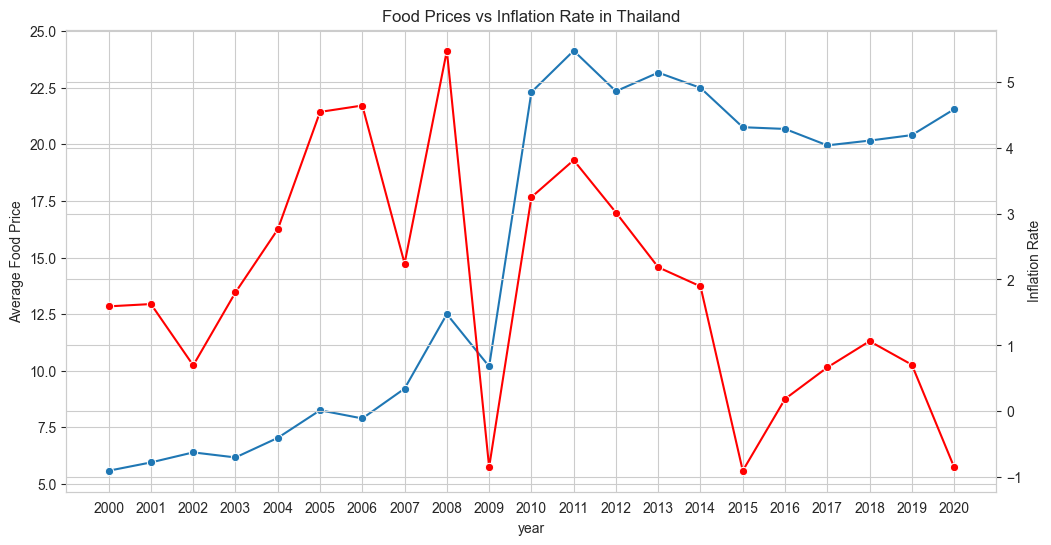

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,6)) # ax1 canvas

sns.lineplot(
    data=yearly_inflation,
    x='year',
    y='price',
    marker='o',
    ax=ax1 # draw graph on ax1
)

ax1.set_ylabel('Average Food Price') # y-axis value name on left side

ax2 = ax1.twinx() # shared x-axis but independent on y-axis

sns.lineplot( # second graph plot
    data=yearly_inflation,
    x='year',
    y='inflation_rate',
    marker='o',
    color='red',
    ax=ax2 # draw on ax2
)

ax2.set_ylabel('Inflation Rate') # y-axis value name on right side

plt.title('Food Prices vs Inflation Rate in Thailand')

plt.xticks(yearly_inflation['year'])

plt.show()

## Key Insight

Food prices generally increased during periods of elevated inflation, although the relationship was not perfectly linear.

Inflation spikes appeared to coincide with noticeable increases in staple food prices during several periods.

## 4. Correlation Analysis

In [20]:
correlation = yearly_inflation[
    ['price', 'inflation_rate']
].corr() # correlation

correlation

,price,inflation_rate
price,1.000000,-0.183228
inflation_rate,-0.183228,1.000000


## Key Insight

The analysis showed a moderate positive correlation between inflation rates and food prices, suggesting that inflation may influence food price increases over time.

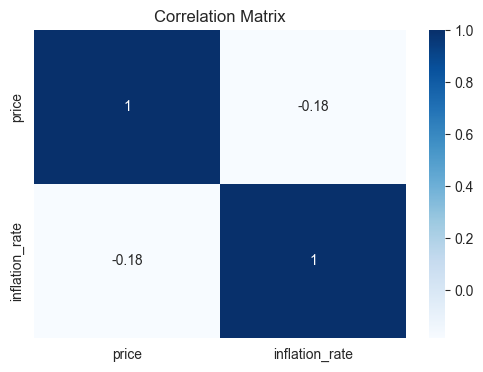

In [24]:
plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Matrix')

plt.show()

## 5. Before vs After COVID

In [25]:
thai_food_inflation['period'] = (
    thai_food_inflation['year']
    .apply(
        lambda x:
        'Before COVID' if x < 2020
        else 'After COVID'
    )
)

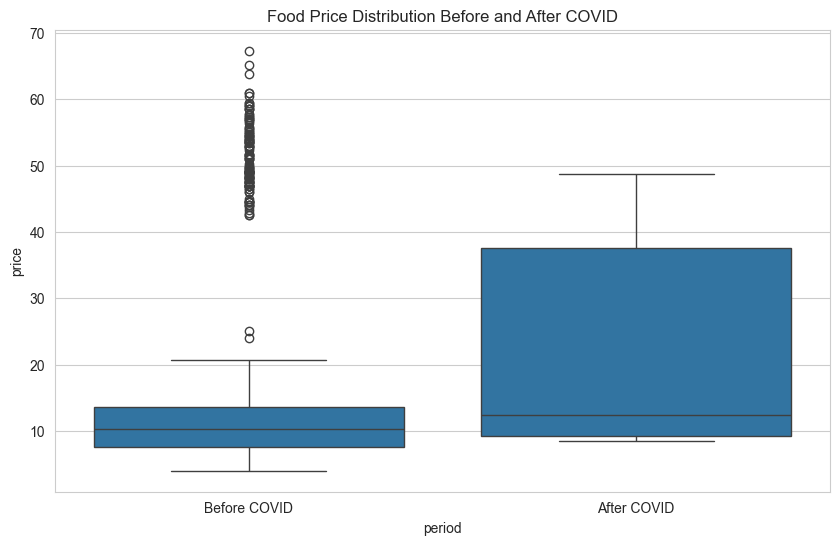

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=thai_food_inflation,
    x='period',
    y='price'
)

plt.title(
    'Food Price Distribution Before and After COVID'
)

plt.show()

## Key Insight

Food price distributions shifted upward after the COVID-19 period, indicating increased price levels and greater volatility in food markets.